# Analiza podatkov Tour de France 2026

V projektu analiziramo podatke o Tour de France 2026, pridobljene s spletne strani ProCyclingStats.

Podatki so shranjeni v CSV datotekah:
- `tour_2026_etape.csv` – splošni podatki o vsaki etapi,
- `tour_2026_kolesarji.csv` – podatki o kolesarjih, udeleženih na Touru,
- `tour_2026_rezultati.csv` – rezultati vsakega kolesarja na posamezni etapi,
- `tour_2026_razsirjeno.csv` – združeni podatki o etapah, kolesarjih in rezultatih,
- `tour_2026_breakaway.csv` – podatki o ubežnikih posameznih etap.

V zvezku pogledamo:
1. Profil celotnega Toura
2. Hitrost zmagovalca skozi Tour
3. Hitrost v odvisnosti od težavnosti etape
4. Starost udeležencev
5. Razvoj vrstnega reda najboljših
6. Zaostanke najboljših po vsaki etapi
7. Porazdelitev zaostankov v etapi
8. Koliko kolesarjev je še ostalo v dirki
9. Velikost pobegov
10. Kilometre v pobegu
11. Zmage glede na tip kolesarja
12. Specializacijo in končni rezultat
13. Najpogostejše narodnosti
14. Kolesarje z največ etapnimi zmagami
15. Etapne zmage po ekipah
16. Povezavo med težo in končno uvrstitvijo


## Uvoz knjižnic in podatkov

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titleweight": "bold",
    "grid.alpha": 0.25
})

etape = pd.read_csv("data/tour_2026_etape.csv")
rezultati = pd.read_csv("data/tour_2026_rezultati.csv")
kolesarji = pd.read_csv("data/tour_2026_kolesarji.csv")
pobegi = pd.read_csv("data/tour_2026_breakaway.csv")

st_etap = int(etape["stage"].max())
etape_osi = range(1, st_etap + 1)

print("Etape:", len(etape))
print("Kolesarji:", len(kolesarji))
print("Rezultati:", len(rezultati))
print("Zapisi o pobegih:", len(pobegi))


Etape: 21
Kolesarji: 184
Rezultati: 3637
Zapisi o pobegih: 475


## 1. Profil celotnega Toura

Višinski metri so dober približek zahtevnosti posamezne etape. Z grafom želimo videti, kako so bile ravninske in gorske etape razporejene skozi Tour ter kje so bili najtežji dnevi.

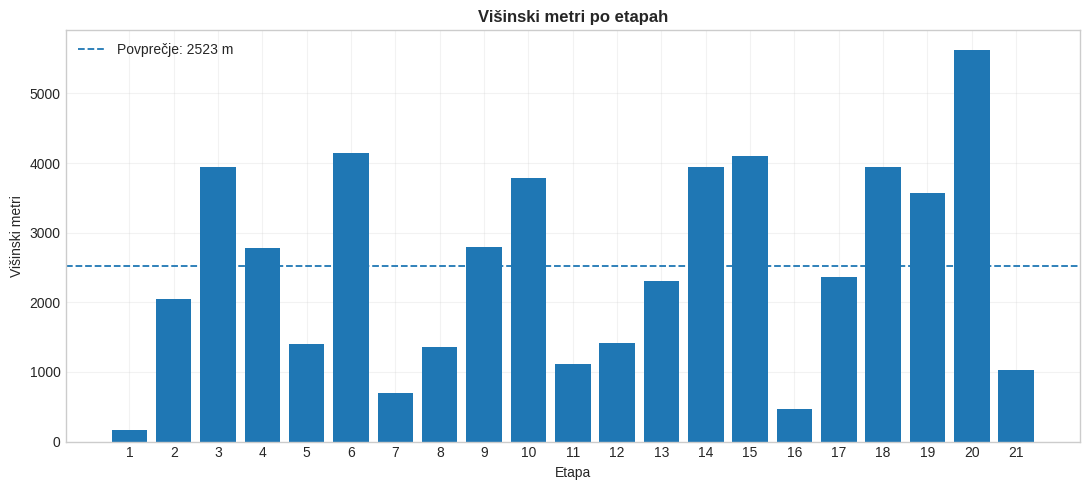

In [2]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(etape["stage"], etape["vertical_meters"])

povprecje = etape["vertical_meters"].mean()
ax.axhline(
    povprecje,
    linestyle="--",
    linewidth=1.3,
    label=f"Povprečje: {povprecje:.0f} m"
)

ax.set_title("Višinski metri po etapah")
ax.set_xlabel("Etapa")
ax.set_ylabel("Višinski metri")
ax.set_xticks(list(etape_osi))
ax.legend()

plt.tight_layout()
plt.show()


Največ višinskih metrov je imela **20. etapa (5624 m)**, sledila pa je 6. etapa z 4149 m. Povprečna etapa je imela približno 2523 višinskih metrov, najtežje gorske etape pa so se pojavljale predvsem v drugi polovici Toura.

## 2. Hitrost zmagovalca skozi Tour

Povprečna hitrost zmagovalca pokaže, kako različen je lahko tempo posameznih etap. Zanimivo je predvsem primerjati hitre ravninske etape s počasnejšimi gorskimi etapami.

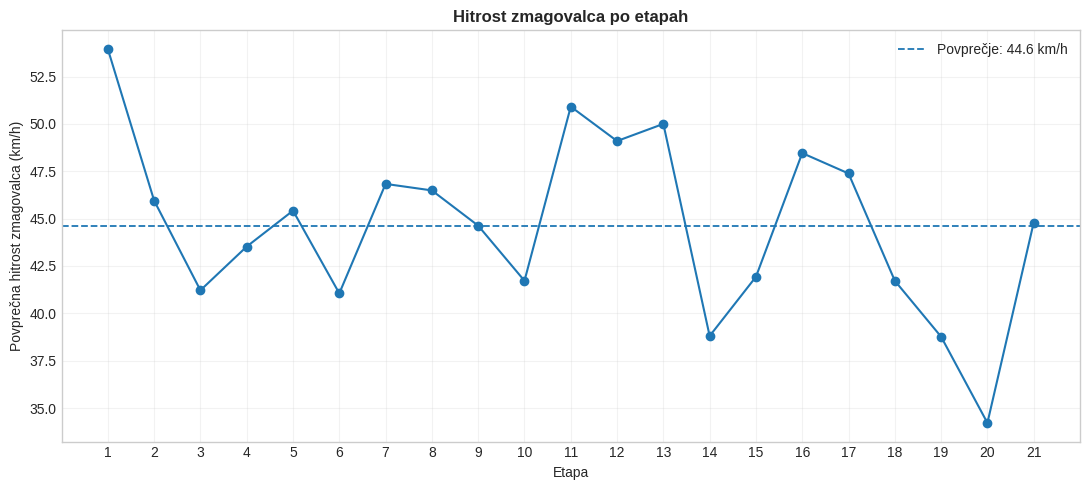

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    etape["stage"],
    etape["avg_speed_winner_kmh"],
    marker="o"
)

povprecje = etape["avg_speed_winner_kmh"].mean()
ax.axhline(
    povprecje,
    linestyle="--",
    linewidth=1.3,
    label=f"Povprečje: {povprecje:.1f} km/h"
)

ax.set_title("Hitrost zmagovalca po etapah")
ax.set_xlabel("Etapa")
ax.set_ylabel("Povprečna hitrost zmagovalca (km/h)")
ax.set_xticks(list(etape_osi))
ax.legend()

plt.tight_layout()
plt.show()


Najhitrejša je bila **1. etapa** s povprečno hitrostjo približno **54,0 km/h**, najpočasnejša pa 20. etapa s **34,2 km/h**. Povprečje vseh etap je bilo približno 44,6 km/h, razlike pa lepo odražajo različen profil etap.

## 3. Hitrost v odvisnosti od težavnosti etape

Pričakujemo, da so zahtevnejše etape praviloma počasnejše. S primerjavo `profile_score` in hitrosti lahko preverimo, ali podatki res kažejo takšno povezavo.

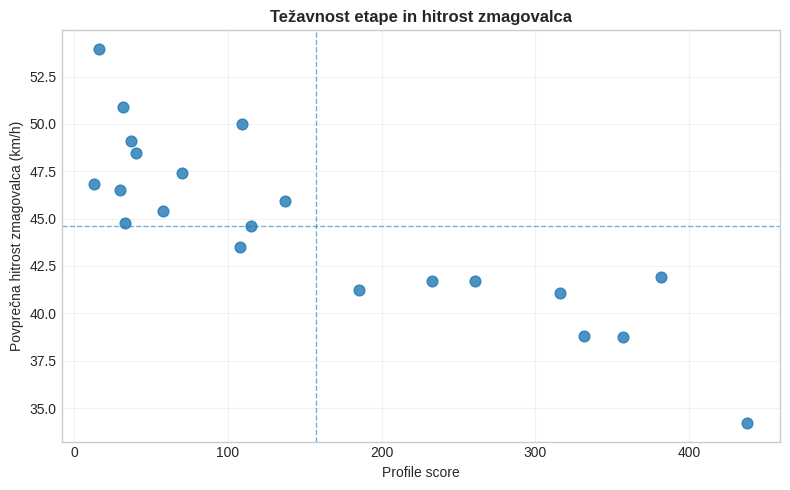

Korelacija: -0.86


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    etape["profile_score"],
    etape["avg_speed_winner_kmh"],
    s=60,
    alpha=0.8
)

ax.axvline(
    etape["profile_score"].mean(),
    linestyle="--",
    linewidth=1,
    alpha=0.6
)
ax.axhline(
    etape["avg_speed_winner_kmh"].mean(),
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

ax.set_title("Težavnost etape in hitrost zmagovalca")
ax.set_xlabel("Profile score")
ax.set_ylabel("Povprečna hitrost zmagovalca (km/h)")

plt.tight_layout()
plt.show()

korelacija = etape["profile_score"].corr(
    etape["avg_speed_winner_kmh"]
)
print(f"Korelacija: {korelacija:.2f}")


Korelacija je približno **−0,86**, kar pomeni precej močno negativno povezavo. Etape z večjim `profile_score` so bile torej praviloma počasnejše, kar je glede na več vzponov in zahtevnejši teren pričakovano.

## 4. Starost udeležencev

Starostna porazdelitev nam pove, kakšen je tipičen profil kolesarja na Touru in kako velik je razpon med najmlajšimi in najstarejšimi udeleženci.

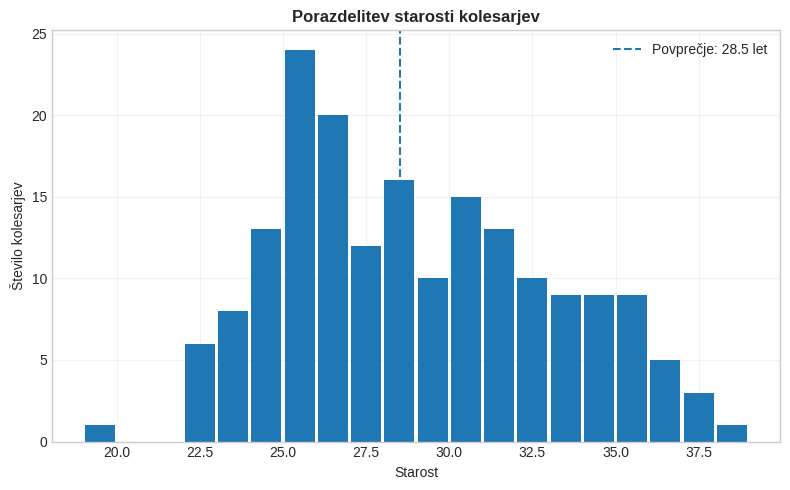

In [5]:
starosti = (
    rezultati
    .drop_duplicates("rider_url")["age"]
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    starosti,
    bins=range(
        int(starosti.min()),
        int(starosti.max()) + 2
    ),
    rwidth=0.9
)

povprecna_starost = starosti.mean()
ax.axvline(
    povprecna_starost,
    linestyle="--",
    linewidth=1.5,
    label=f"Povprečje: {povprecna_starost:.1f} let"
)

ax.set_title("Porazdelitev starosti kolesarjev")
ax.set_xlabel("Starost")
ax.set_ylabel("Število kolesarjev")
ax.legend()

plt.tight_layout()
plt.show()


Kolesarji so bili stari med **19 in 38 let**, povprečna starost pa je bila približno **28,5 leta**. Večina tekmovalcev je skoncentrirana okoli poznih dvajsetih let, kar kaže na mešanico mladih talentov in izkušenih kolesarjev.

## 5. Razvoj vrstnega reda najboljših

Končni rezultat ne pokaže, kako se je boj za skupno razvrstitev razvijal skozi tri tedne. Zato spremljamo končnih pet najboljših in njihove položaje po posameznih etapah.

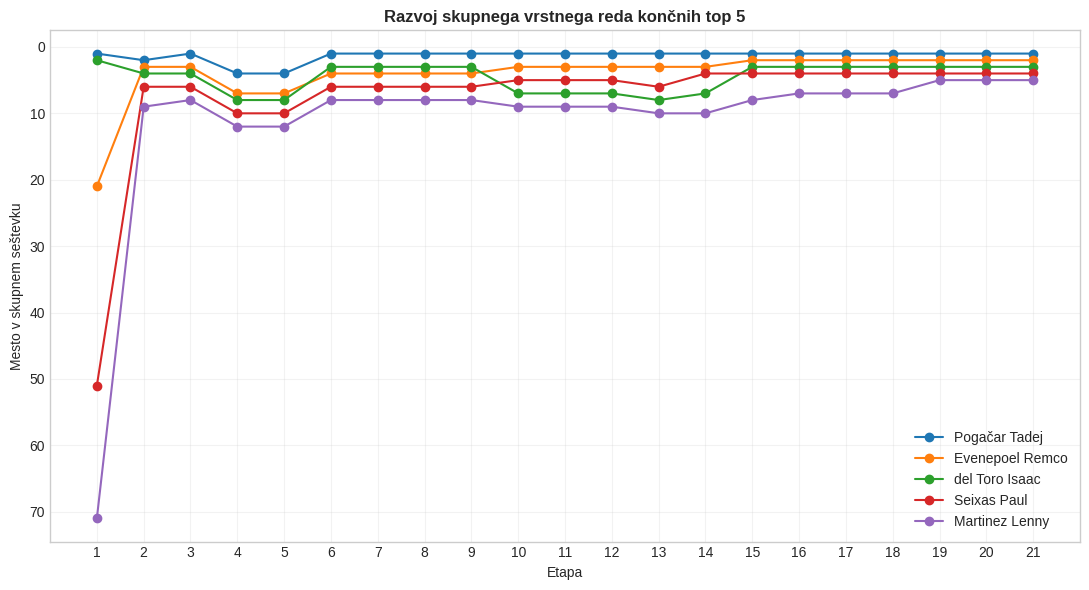

In [6]:
zadnja_etapa = rezultati["stage"].max()

koncni_vrstni_red = (
    rezultati[rezultati["stage"] == zadnja_etapa]
    .dropna(subset=["gc_position"])
    .sort_values("gc_position")
)

top5_url = koncni_vrstni_red.head(5)["rider_url"]

fig, ax = plt.subplots(figsize=(11, 6))

for rider_url in top5_url:
    podatki = (
        rezultati[rezultati["rider_url"] == rider_url]
        .sort_values("stage")
    )

    ax.plot(
        podatki["stage"],
        podatki["gc_position"],
        marker="o",
        label=podatki["rider"].iloc[0]
    )

ax.invert_yaxis()
ax.set_title("Razvoj skupnega vrstnega reda končnih top 5")
ax.set_xlabel("Etapa")
ax.set_ylabel("Mesto v skupnem seštevku")
ax.set_xticks(list(etape_osi))
ax.legend()

plt.tight_layout()
plt.show()


**Tadej Pogačar** je bil že po 1. etapi prvi in je Tour končal na 1. mestu. Remco Evenepoel je napredoval z 21. na 2. mesto, Paul Seixas z 51. na 4., Lenny Martinez pa z 71. na 5. mesto, zato se lepo vidi, kako se je pravi vrstni red oblikoval šele skozi več etap.

## 6. Zaostanki najboljših po vsaki etapi

Dve mesti v skupnem seštevku sta lahko ločeni z nekaj sekundami ali več minutami. Zato poleg položaja primerjamo še dejanske časovne zaostanke končnih petih najboljših.

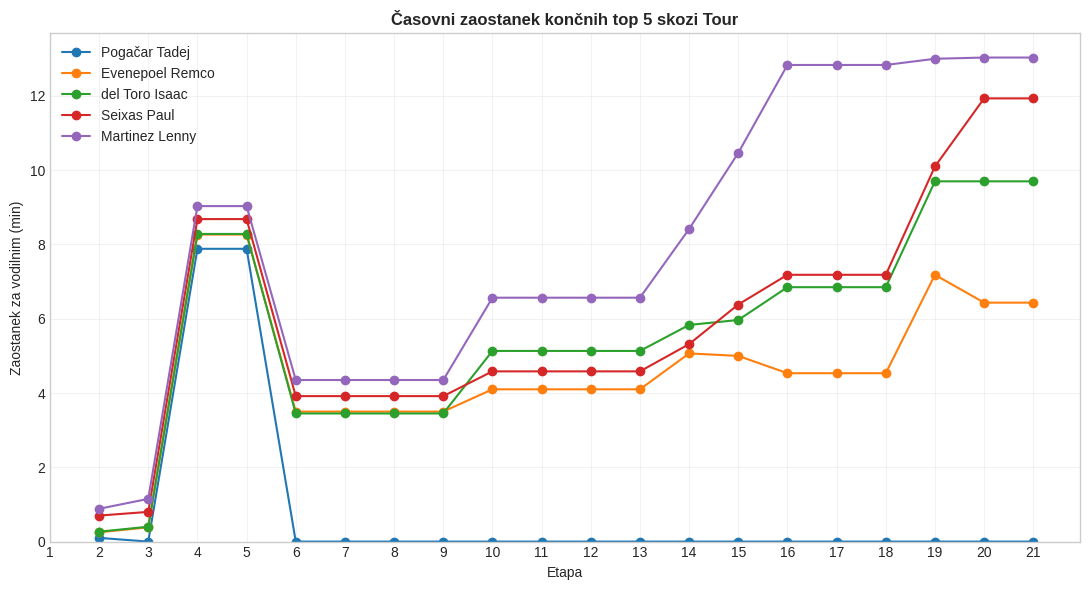

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

for rider_url in top5_url:
    podatki = rezultati[
        (rezultati["rider_url"] == rider_url)
        & rezultati["gc_timelag_seconds"].notna()
    ].sort_values("stage").copy()

    podatki["zaostanek_min"] = (
        podatki["gc_timelag_seconds"] / 60
    )

    ax.plot(
        podatki["stage"],
        podatki["zaostanek_min"],
        marker="o",
        label=podatki["rider"].iloc[0]
    )

ax.set_title("Časovni zaostanek končnih top 5 skozi Tour")
ax.set_xlabel("Etapa")
ax.set_ylabel("Zaostanek za vodilnim (min)")
ax.set_xticks(list(etape_osi))
ax.set_ylim(bottom=0)
ax.legend()

plt.tight_layout()
plt.show()


Pogačar je Tour končal brez zaostanka kot skupni zmagovalec. Evenepoel je zaostal **6 min 26 s**, Isaac del Toro približno **9 min 42 s**, razlika do 5. mesta pa je že presegla 13 minut. Graf pokaže, da se časovne razlike skozi Tour postopoma povečujejo.

## 7. Porazdelitev zaostankov v etapi

Povprečje samo ne pove, ali je večina kolesarjev prišla skupaj ali pa je bila etapa zelo razbita. Boxplot zato uporabimo za primerjavo celotne porazdelitve zaostankov med etapami.

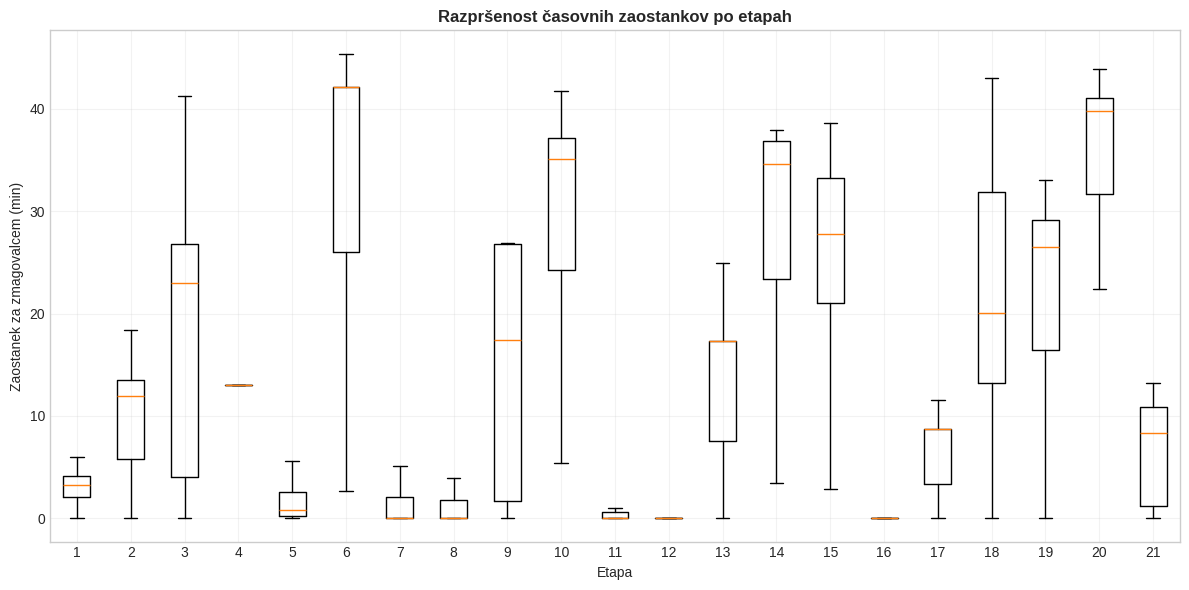

In [8]:
zaostanki_po_etapah = []

for etapa in etape_osi:
    zaostanki = (
        rezultati[
            (rezultati["stage"] == etapa)
            & (rezultati["status"] == "finished")
        ]["stage_gap_seconds"]
        .dropna()
        / 60
    )
    zaostanki_po_etapah.append(zaostanki)

fig, ax = plt.subplots(figsize=(12, 6))

ax.boxplot(
    zaostanki_po_etapah,
    tick_labels=list(etape_osi),
    showfliers=False
)

ax.set_title("Razpršenost časovnih zaostankov po etapah")
ax.set_xlabel("Etapa")
ax.set_ylabel("Zaostanek za zmagovalcem (min)")

plt.tight_layout()
plt.show()


Največji tipični zaostanki so nastali na zahtevnih etapah. Na **6. etapi** je bil mediani zaostanek približno 42 minut, na 20. pa skoraj 40 minut, medtem ko so bile nekatere lažje etape precej bolj strnjene.

## 8. Koliko kolesarjev je še ostalo v dirki

Tour je dolga dirka, zato vsi kolesarji ne pridejo do cilja v Parizu. S številom tekmovalcev po etapah lahko spremljamo postopno zmanjševanje glavnine.

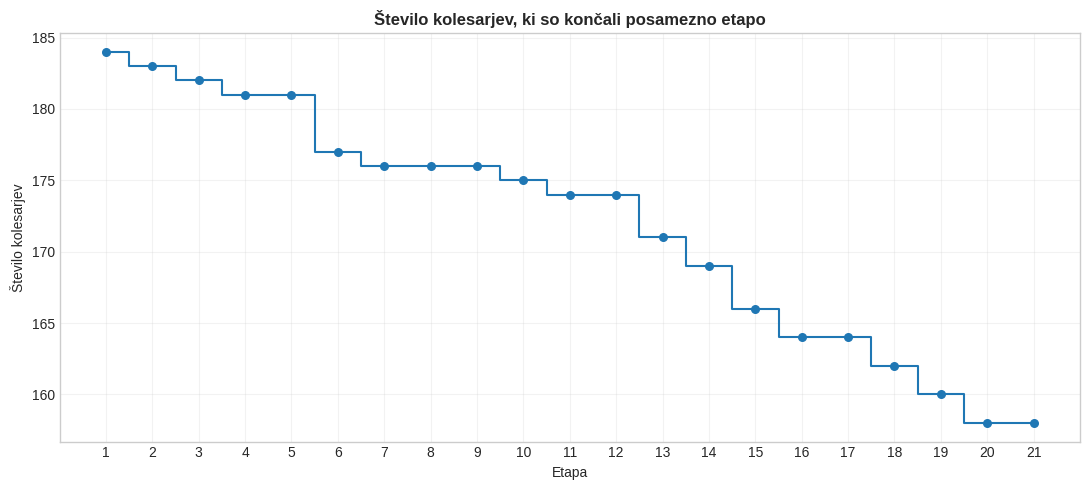

In [9]:
ostali = (
    rezultati[rezultati["status"] == "finished"]
    .groupby("stage")
    .size()
    .reindex(etape_osi)
)

fig, ax = plt.subplots(figsize=(11, 5))

ax.step(
    ostali.index,
    ostali.values,
    where="mid"
)
ax.scatter(
    ostali.index,
    ostali.values,
    s=30
)

ax.set_title("Število kolesarjev, ki so končali posamezno etapo")
ax.set_xlabel("Etapa")
ax.set_ylabel("Število kolesarjev")
ax.set_xticks(list(etape_osi))

plt.tight_layout()
plt.show()


Prvo etapo je končalo **184 kolesarjev**, zadnjo pa **158**, zato je med Tourom odpadlo 26 tekmovalcev. Padec je postopen, nekoliko več kolesarjev pa odpade ob zahtevnejših delih dirke.

## 9. Velikost pobegov

Pobegi so pomemben taktični del cestnega kolesarstva. Zanima nas, na katerih etapah je bilo v pobegu največ različnih kolesarjev in kako se je napadalnost spreminjala skozi Tour.

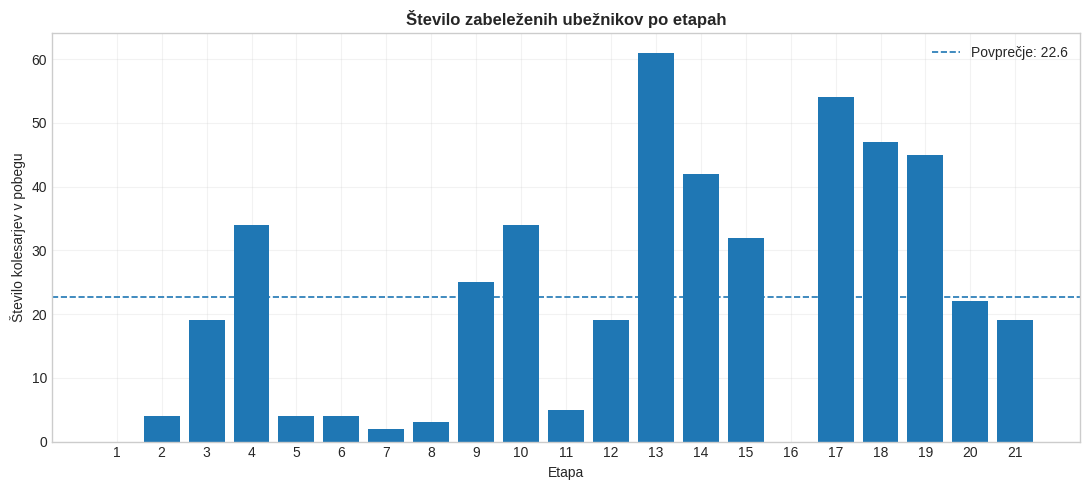

In [10]:
stevilo_ubeznikov = (
    pobegi.groupby("stage")["rider_url"]
    .nunique()
    .reindex(etape_osi, fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 5))

stolpci = ax.bar(
    stevilo_ubeznikov.index,
    stevilo_ubeznikov.values
)

povprecje = stevilo_ubeznikov.mean()
ax.axhline(
    povprecje,
    linestyle="--",
    linewidth=1.2,
    label=f"Povprečje: {povprecje:.1f}"
)

ax.set_title("Število zabeleženih ubežnikov po etapah")
ax.set_xlabel("Etapa")
ax.set_ylabel("Število kolesarjev v pobegu")
ax.set_xticks(list(etape_osi))
ax.legend()

plt.tight_layout()
plt.show()


Največ različnih ubežnikov je bilo na **13. etapi (61)**, zelo veliki pobegi pa so nastali tudi na 17., 18. in 19. etapi. V zgodnejših etapah so bili pobegi praviloma manj številčni, kar kaže na več napadalnega dirkanja v drugi polovici Toura.

## 10. Kilometri v pobegu

Samo število pobegov ne pove, kdo je bil najbolj aktiven. Zato seštejemo kilometre pred glavnino in spremljamo, kako jih je pet najaktivnejših kolesarjev nabiralo skozi dirko.

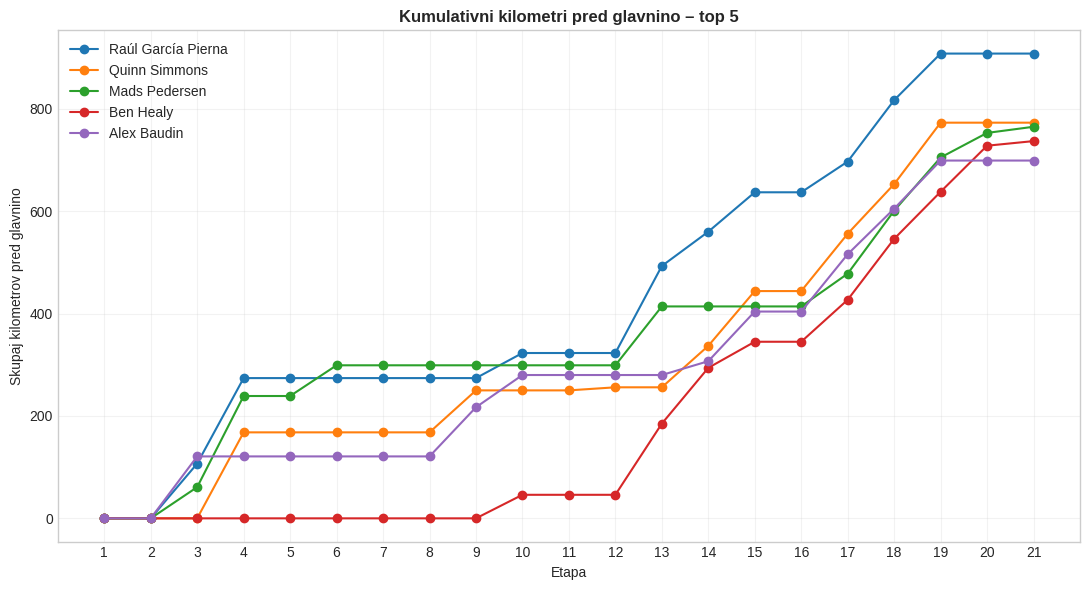

In [11]:
pobegi_z_imeni = pobegi.merge(
    kolesarji[["rider_url", "rider"]],
    on="rider_url",
    how="left",
    suffixes=("_pcs", "")
)

pobegi_po_etapah = (
    pobegi_z_imeni.groupby(
        ["rider_url", "rider", "stage"],
        as_index=False
    )["km_before_peloton"]
    .sum()
)

najvec_km = (
    pobegi_po_etapah
    .groupby(["rider_url", "rider"])["km_before_peloton"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

fig, ax = plt.subplots(figsize=(11, 6))

for rider_url, ime in najvec_km.index:
    podatki = (
        pobegi_po_etapah[
            pobegi_po_etapah["rider_url"] == rider_url
        ]
        .set_index("stage")["km_before_peloton"]
        .reindex(etape_osi, fill_value=0)
        .cumsum()
    )

    ax.plot(
        podatki.index,
        podatki.values,
        marker="o",
        label=ime
    )

ax.set_title("Kumulativni kilometri pred glavnino – top 5")
ax.set_xlabel("Etapa")
ax.set_ylabel("Skupaj kilometrov pred glavnino")
ax.set_xticks(list(etape_osi))
ax.legend()

plt.tight_layout()
plt.show()


Največ kilometrov pred glavnino je zbral **Raúl García Pierna (908 km)**, sledita Quinn Simmons s 773 km in Mads Pedersen s 765 km. Razlike med črtami pokažejo tudi, v katerem delu Toura je posamezen kolesar največ napadal.

## 11. Zmage glede na tip kolesarja

Različni tipi kolesarjev imajo prednost na različnih profilih etap. S številom zmag po specializacijah lahko preverimo, kateri tip je bil na Touru 2026 najuspešnejši.

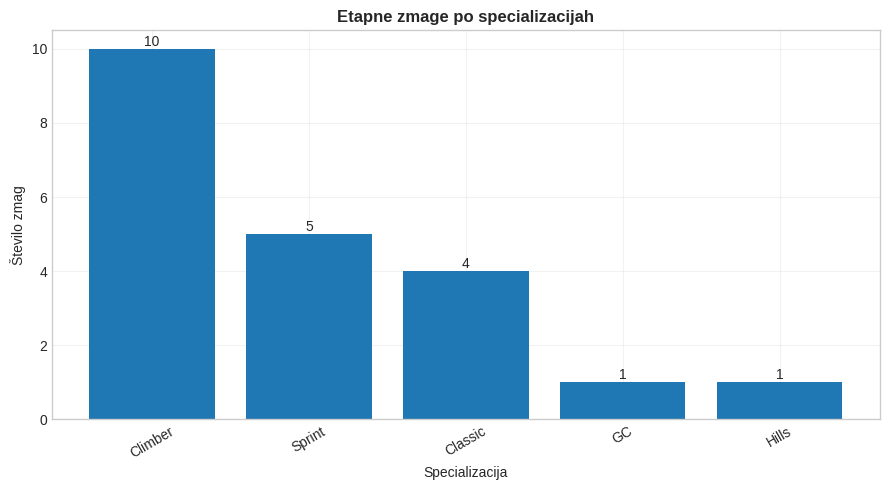

In [12]:
zmagovalci = rezultati[
    (rezultati["rank"] == 1)
    & (rezultati["status"] == "finished")
]

zmage_po_tipih = (
    zmagovalci["specialty"]
    .value_counts()
)

fig, ax = plt.subplots(figsize=(9, 5))

stolpci = ax.bar(
    zmage_po_tipih.index,
    zmage_po_tipih.values
)

ax.bar_label(stolpci)

ax.set_title("Etapne zmage po specializacijah")
ax.set_xlabel("Specializacija")
ax.set_ylabel("Število zmag")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


Kolesarji s specializacijo **Climber** so osvojili kar **10 etap**, sprinterji 5, specialisti za klasike pa 4. To se ujema z velikim številom zahtevnih in gorskih etap na letošnjem Touru.

## 12. Specializacija in končni rezultat

Etapne zmage niso edino merilo uspeha. Zanima nas še, kateri tipi kolesarjev se praviloma bolje uvrstijo v skupnem seštevku po treh tednih dirkanja.

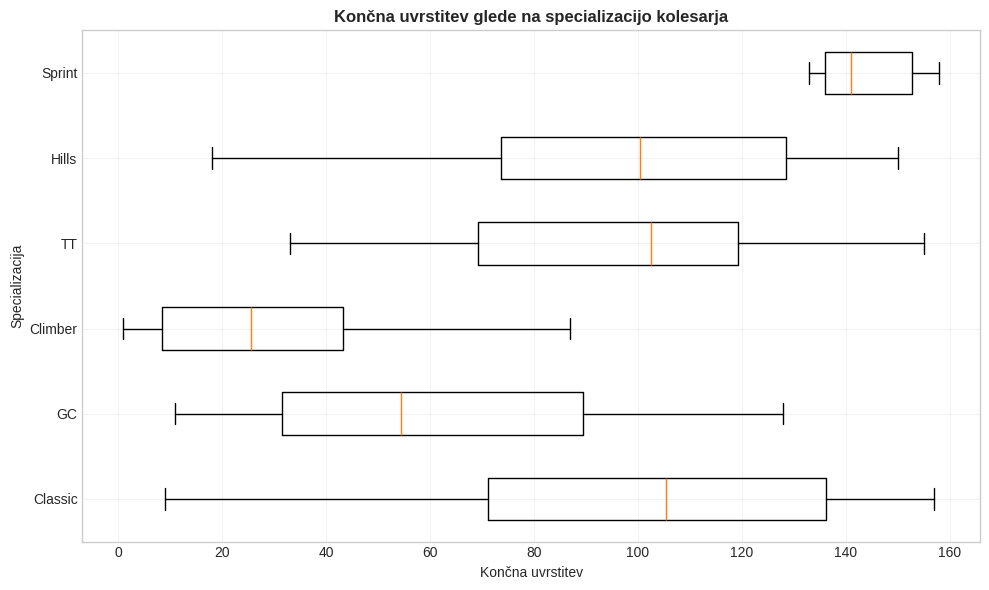

In [13]:
koncni = rezultati[
    (rezultati["stage"] == zadnja_etapa)
    & rezultati["gc_position"].notna()
    & rezultati["specialty"].notna()
].copy()

najpogostejsi_tipi = (
    koncni["specialty"]
    .value_counts()
    .head(6)
    .index
)

podatki_za_boxplot = [
    koncni[
        koncni["specialty"] == tip
    ]["gc_position"]
    for tip in najpogostejsi_tipi
]

fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(
    podatki_za_boxplot,
    tick_labels=najpogostejsi_tipi,
    vert=False,
    showfliers=False
)

ax.set_title("Končna uvrstitev glede na specializacijo kolesarja")
ax.set_xlabel("Končna uvrstitev")
ax.set_ylabel("Specializacija")

plt.tight_layout()
plt.show()


Najboljšo mediano končne uvrstitve imajo **climberji (25,5. mesto)**. Sprinterji imajo mediano okoli 141. mesta, kar je pričakovano, saj so njihove prednosti pomembnejše pri etapnih zmagah kot pri skupni razvrstitvi.

## 13. Najpogostejše narodnosti

Tour de France je mednarodna dirka, zato je zanimivo pogledati, iz katerih držav prihaja največ udeležencev. Zaradi preglednosti prikažemo deset najpogostejših narodnosti.

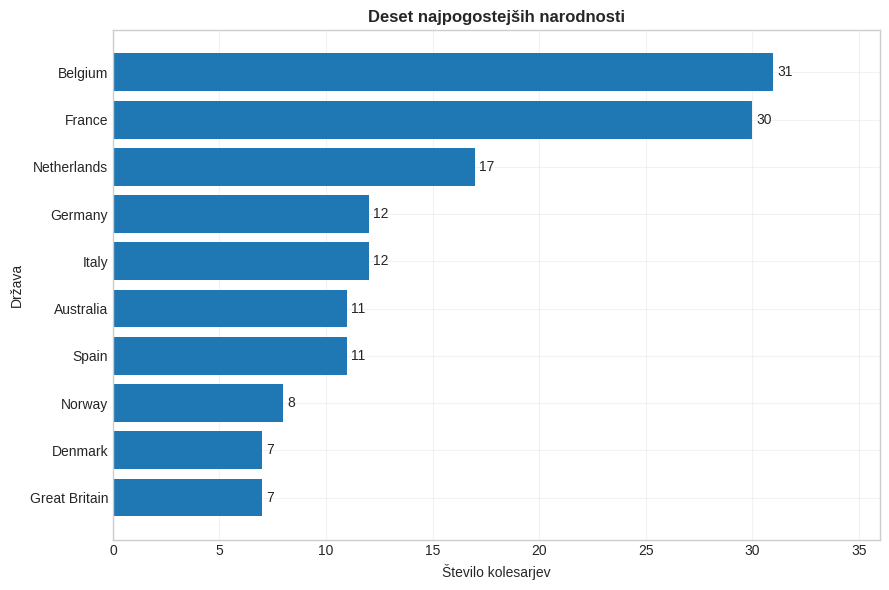

In [14]:
narodnosti = (
    kolesarji["nationality"]
    .value_counts()
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 6))

stolpci = ax.barh(
    narodnosti.index,
    narodnosti.values
)

ax.bar_label(
    stolpci,
    padding=3
)

ax.set_title("Deset najpogostejših narodnosti")
ax.set_xlabel("Število kolesarjev")
ax.set_ylabel("Država")
ax.set_xlim(0, narodnosti.max() + 5)

plt.tight_layout()
plt.show()


Največ udeležencev je prihajalo iz **Belgije (31)** in **Francije (30)**, precej zadaj pa je bila Nizozemska s 17 kolesarji. Med desetimi najpogostejšimi državami prevladujejo evropske kolesarske velesile, kar je za Tour pričakovano.

## 14. Kolesarji z največ etapnimi zmagami

Skupni vrstni red pokaže uspeh skozi celoten Tour, vendar so zelo pomembne tudi posamezne etapne zmage. Zato pogledamo, kateri kolesarji so na Touru 2026 osvojili največ etap.

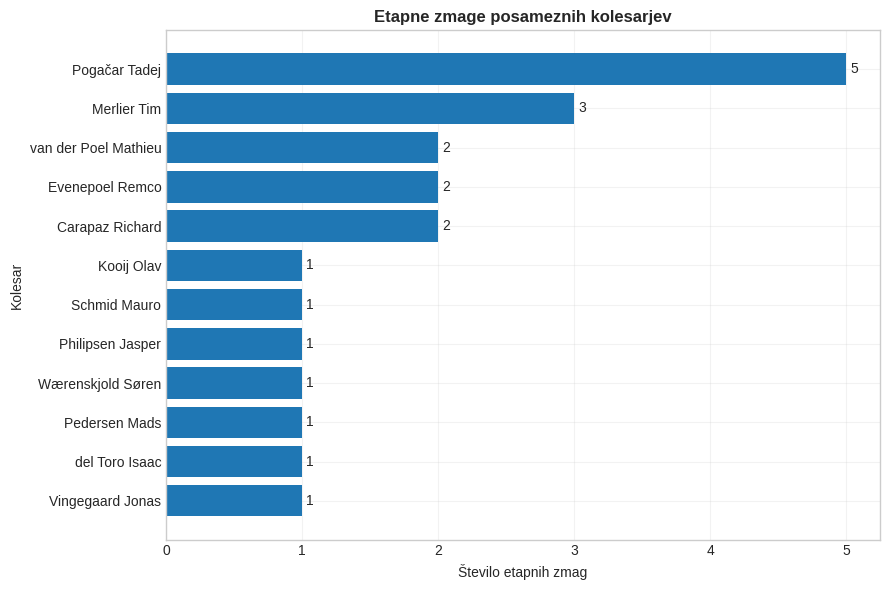

In [15]:
zmage_kolesarjev = (
    rezultati[
        (rezultati["rank"] == 1)
        & (rezultati["status"] == "finished")
    ]["rider"]
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 6))

stolpci = ax.barh(
    zmage_kolesarjev.index,
    zmage_kolesarjev.values
)

ax.bar_label(
    stolpci,
    padding=3
)

ax.set_title("Etapne zmage posameznih kolesarjev")
ax.set_xlabel("Število etapnih zmag")
ax.set_ylabel("Kolesar")
ax.set_xticks(
    range(0, int(zmage_kolesarjev.max()) + 1)
)

plt.tight_layout()
plt.show()


Največ etapnih zmag je dosegel **Tadej Pogačar**, ki je osvojil **6 etap**. Večina ostalih etapnih zmagovalcev je zmagala enkrat ali dvakrat, zato je njegova prevlada opazna tudi na ravni posameznih etap in ne samo v skupnem seštevku.

## 15. Etapne zmage po ekipah

Poleg uspeha posameznih kolesarjev je Tour pomembno tudi ekipno tekmovanje. Z grafom želimo ugotoviti, katere ekipe so na dirki osvojile največ etap.

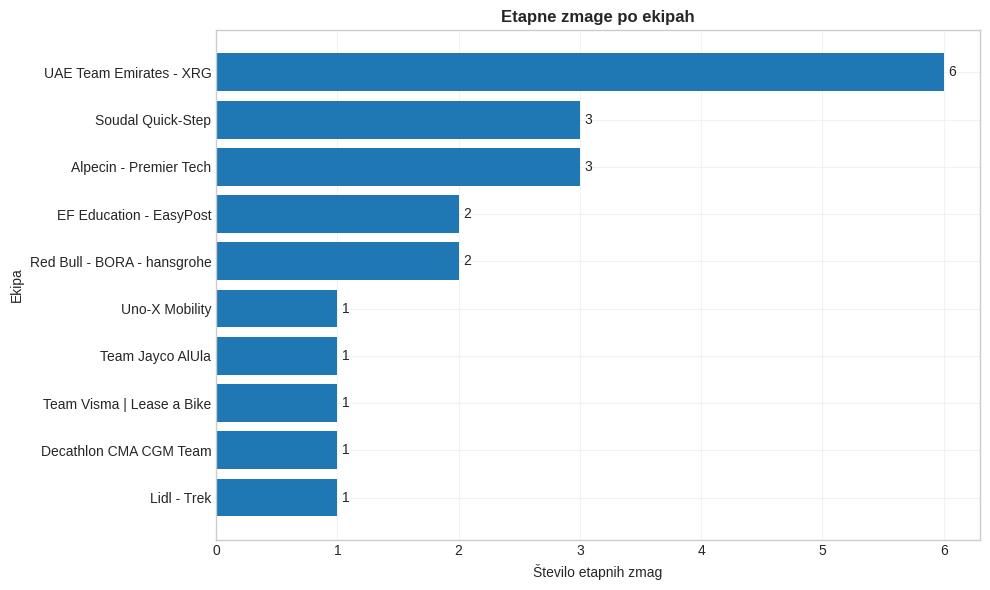

In [16]:
zmagovalci = rezultati[
    (rezultati["rank"] == 1)
    & (rezultati["status"] == "finished")
]

zmage_ekip = (
    zmagovalci["team"]
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))

stolpci = ax.barh(
    zmage_ekip.index,
    zmage_ekip.values
)

ax.bar_label(
    stolpci,
    padding=3
)

ax.set_title("Etapne zmage po ekipah")
ax.set_xlabel("Število etapnih zmag")
ax.set_ylabel("Ekipa")
ax.set_xticks(
    range(0, int(zmage_ekip.max()) + 1)
)

plt.tight_layout()
plt.show()


Najuspešnejša je bila ekipa **UAE Team Emirates - XRG** s **6 etapnimi zmagami**. Alpecin - Premier Tech in Soudal Quick-Step sta osvojila po 3 etape, ostale ekipe pa največ dve. Uspeh UAE je povezan tudi z zelo uspešnim nastopom njihovih najboljših kolesarjev.

## 16. Teža in končna uvrstitev

Na tritedenski dirki z veliko vzponi imajo lažji kolesarji pogosto prednost v skupnem seštevku. Zato primerjamo težo tekmovalcev z njihovo končno uvrstitvijo na Touru.

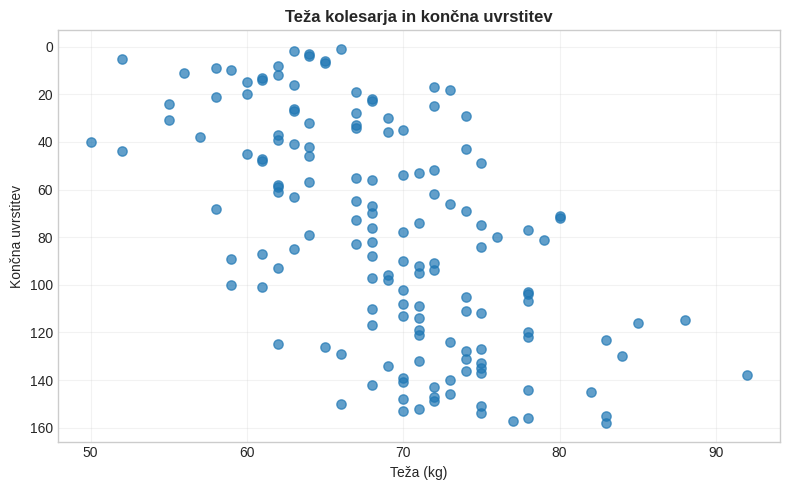

Korelacija med težo in številko uvrstitve: 0.59
Povprečna teža kolesarjev v top 20: 62.6 kg


In [17]:
koncni_s_tezo = (
    rezultati[
        (rezultati["stage"] == zadnja_etapa)
        & rezultati["gc_position"].notna()
    ][["rider_url", "gc_position"]]
    .merge(
        kolesarji[["rider_url", "weight_kg"]],
        on="rider_url",
        how="left"
    )
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    koncni_s_tezo["weight_kg"],
    koncni_s_tezo["gc_position"],
    s=45,
    alpha=0.7
)

ax.invert_yaxis()

ax.set_title("Teža kolesarja in končna uvrstitev")
ax.set_xlabel("Teža (kg)")
ax.set_ylabel("Končna uvrstitev")

plt.tight_layout()
plt.show()

korelacija_teza_uvrstitev = (
    koncni_s_tezo["weight_kg"]
    .corr(koncni_s_tezo["gc_position"])
)

top20_povprecje = (
    koncni_s_tezo[
        koncni_s_tezo["gc_position"] <= 20
    ]["weight_kg"]
    .mean()
)

print(
    f"Korelacija med težo in številko uvrstitve: "
    f"{korelacija_teza_uvrstitev:.2f}"
)
print(
    f"Povprečna teža kolesarjev v top 20: "
    f"{top20_povprecje:.1f} kg"
)


Korelacija med težo in številko končne uvrstitve je približno **0,59**. Ker manjša številka pomeni boljšo uvrstitev, podatki kažejo, da so bili lažji kolesarji praviloma uspešnejši v skupnem seštevku. Povprečna teža kolesarjev v končnih top 20 je bila približno **62,7 kg**. Seveda sama teža ne določa rezultata, saj imajo velik vpliv tudi specializacija, forma in taktika.

# Zaključek

Analiza Tour de France 2026 pokaže, da so zahtevnejše etape praviloma počasnejše in pomembno vplivajo na oblikovanje skupnega vrstnega reda. Tadej Pogačar je bil najuspešnejši tako v skupnem seštevku kot po številu etapnih zmag, climberji pa so bili nasploh najuspešnejša specializacija. Pobegi so bili izrazitejši predvsem v drugi polovici Toura, medtem ko je število kolesarjev skozi dirko postopoma upadalo. Podatki tako pokažejo, da na uspeh vplivajo profil etap, specializacija kolesarja, taktika in sposobnost ohranjanja forme skozi celotno dirko.

# Možne razširitve

Projekt bi lahko razširili s podrobnejšo primerjavo ekip, analizo uspešnosti pobegov ter vključitvijo več značilnosti kolesarjev hkrati, na primer starosti, teže in specializacije. Zanimiva bi bila tudi primerjava Toura 2026 s prejšnjimi izvedbami, saj bi tako lahko opazovali spremembe v hitrosti, zahtevnosti etap, številu odstopov in uspešnosti različnih tipov kolesarjev skozi čas.